<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  4.46MB/s    in 34s     

2026-10-05 14:14:28 (4.49 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [6]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [7]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



                    JobSatPoints_6  JobSatPoints_7
Age                                               
Under 18 years old             1.5             5.0
18-24 years old               15.0            20.0
25-34 years old               20.0            15.0
35-44 years old               20.0            15.0
45-54 years old               20.0            15.0
55-64 years old               20.0            20.0
65 years or older             20.0            15.0
Prefer not to say             10.0             7.0

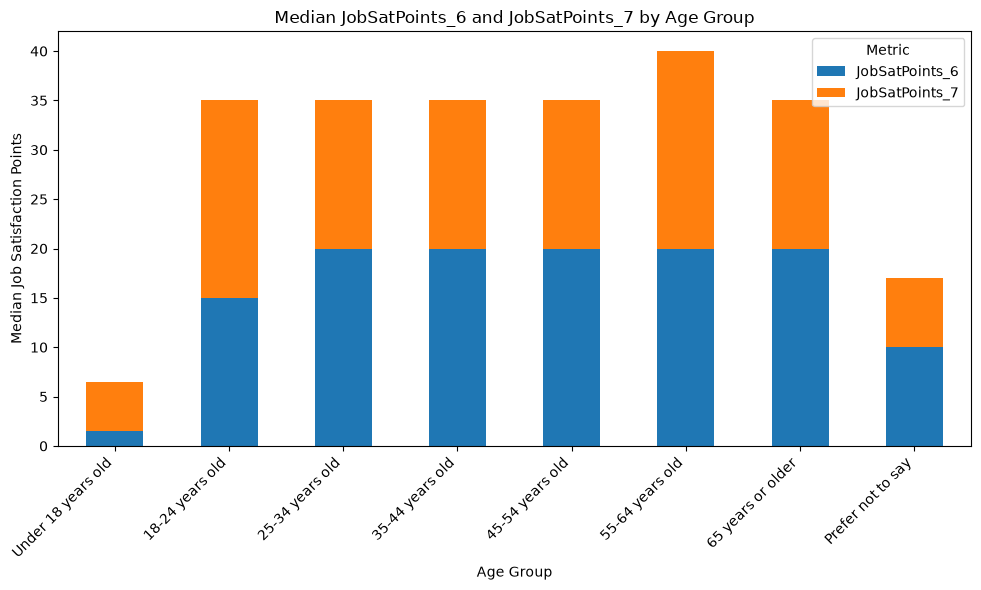

In [12]:
##Write your code here
# 1) groupby su Age, 2) selezione delle due colonne, 3) mediana
median_sat = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()
# ordine logico delle fasce d'eta (tiene solo quelle presenti)
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older', 'Prefer not to say']
median_sat = median_sat.reindex([a for a in age_order if a in median_sat.index])
print(median_sat)
# 4) grafico a barre impilate
median_sat.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Median JobSatPoints_6 and JobSatPoints_7 by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Job Satisfaction Points')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


                                                    JobSatPoints_6  \
Employment                                                           
Employed, full-time                                           20.0   
Employed, part-time                                           15.0   
I prefer not to say                                            NaN   
Independent contractor, freelancer, or self-emp...            15.0   
Not employed, and not looking for work                        10.0   
Not employed, but looking for work                            10.0   
Retired                                                       10.0   
Student, full-time                                            10.0   
Student, part-time                                            15.0   

                                                    JobSatPoints_7  
Employment                                                          
Employed, full-time                                           15.0  
Employed, part-time   

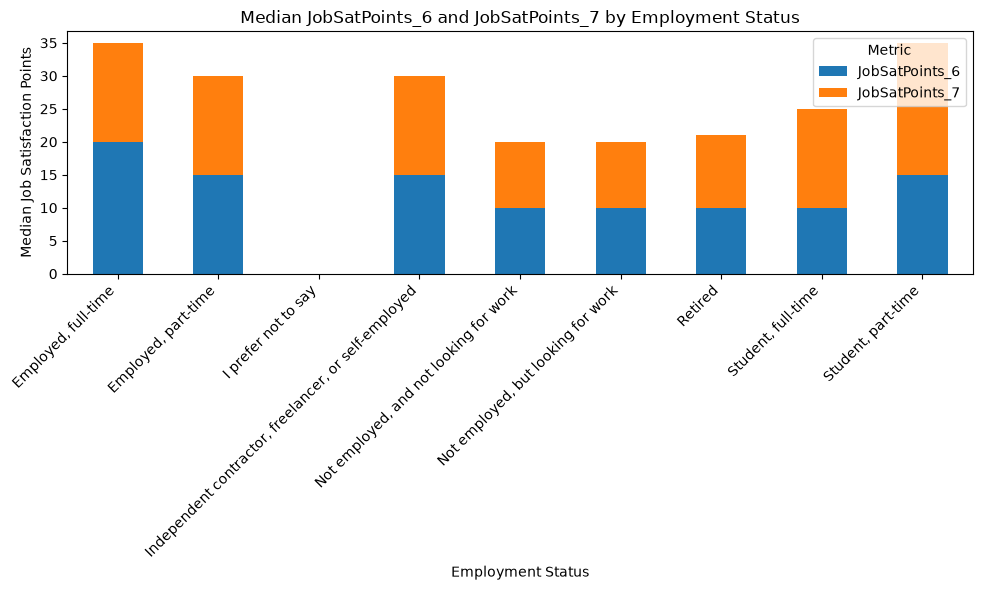

In [13]:
##Write your code here
# Employment puo contenere piu valori separati da ';' -> li separo su righe diverse
emp = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']].dropna(subset=['Employment']).copy()
emp['Employment'] = emp['Employment'].str.split(';')
emp = emp.explode('Employment')
# stesso schema del grafico precedente: groupby, selezione colonne, mediana
median_emp = emp.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median()
print(median_emp)
median_emp.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Median JobSatPoints_6 and JobSatPoints_7 by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Median Job Satisfaction Points')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


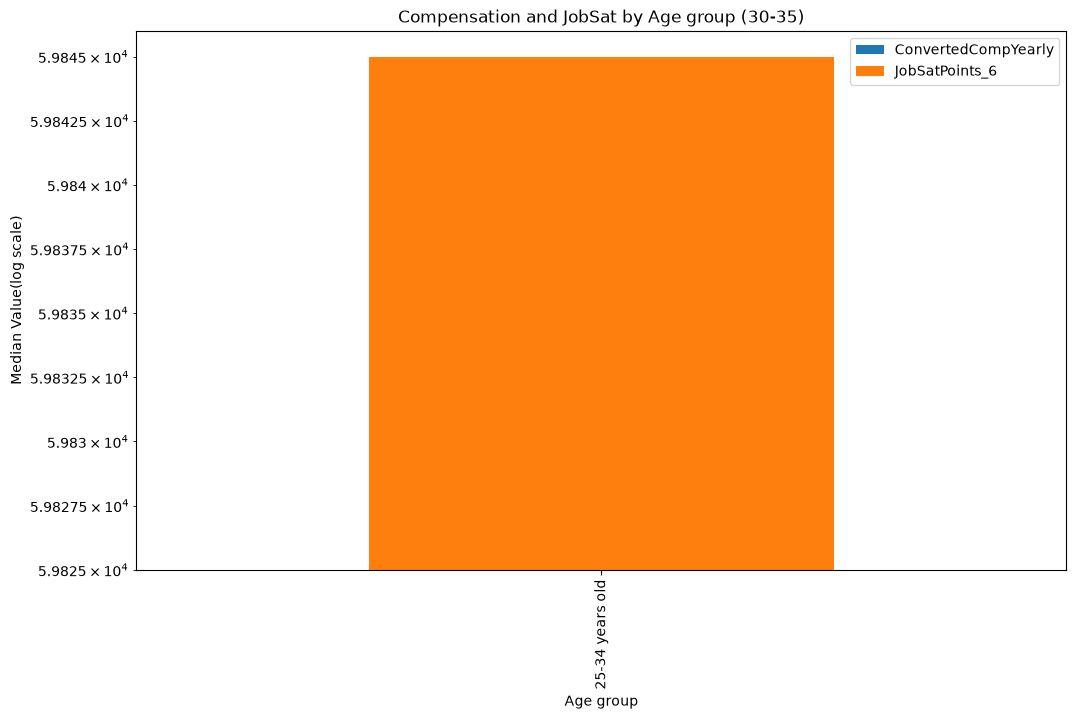

In [21]:
##Write your code here
age=df['Age']== '25-34 years old'
age30=df.loc[age, ['Age', 'ConvertedCompYearly', 'JobSatPoints_6']]
median_age=age30.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()

median_age.plot(kind='bar', stacked=True, figsize=(12,7), logy=True) 
plt.title('Compensation and JobSat by Age group (30-35)')
plt.xlabel('Age group')
plt.ylabel('Median Value(log scale)')
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


                    ConvertedCompYearly  JobSatPoints_6
Age                                                    
Under 18 years old               7.6265             1.5
18-24 years old                 25.0000            15.0
25-34 years old                 59.8250            20.0
35-44 years old                 84.7960            20.0
45-54 years old                 99.0990            20.0
55-64 years old                109.6910            20.0
65 years or older              106.0000            20.0
Prefer not to say              140.0000            10.0

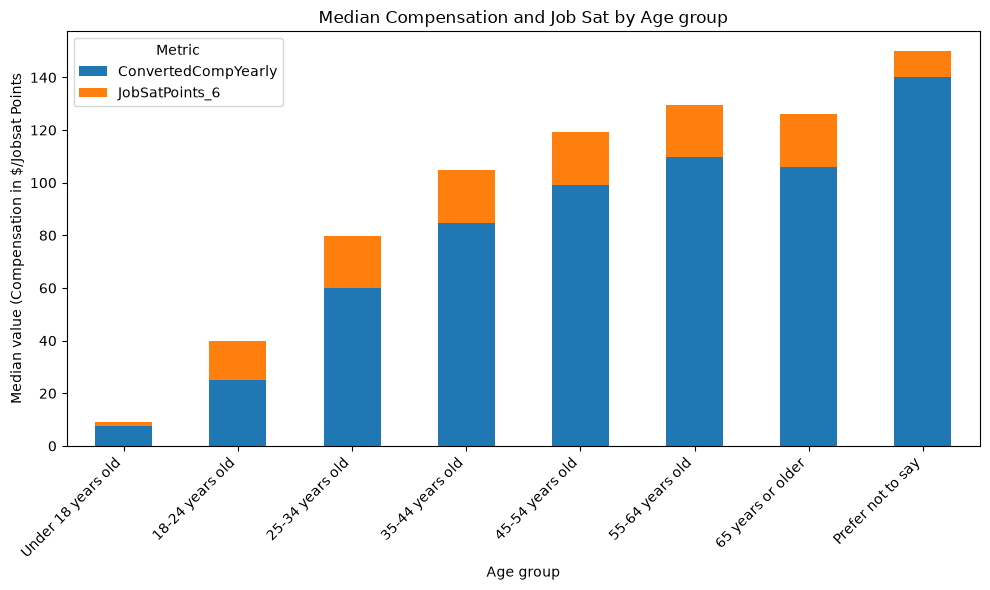

In [27]:
##Write your code here
median_sat=df.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older', 'Prefer not to say']
median_sat=median_sat.reindex(a for a in age_order if a in median_sat.index)
median_sat['ConvertedCompYearly'] = median_sat['ConvertedCompYearly'] / 1000
print(median_sat)

median_sat.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Median Compensation and Job Sat by Age group')
plt.xlabel('Age group') 
plt.ylabel('Median value (Compensation in $/Jobsat Points') 
plt.xticks(rotation= 45, ha='right') 
plt.legend(title='Metric') 
plt.tight_layout() 
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


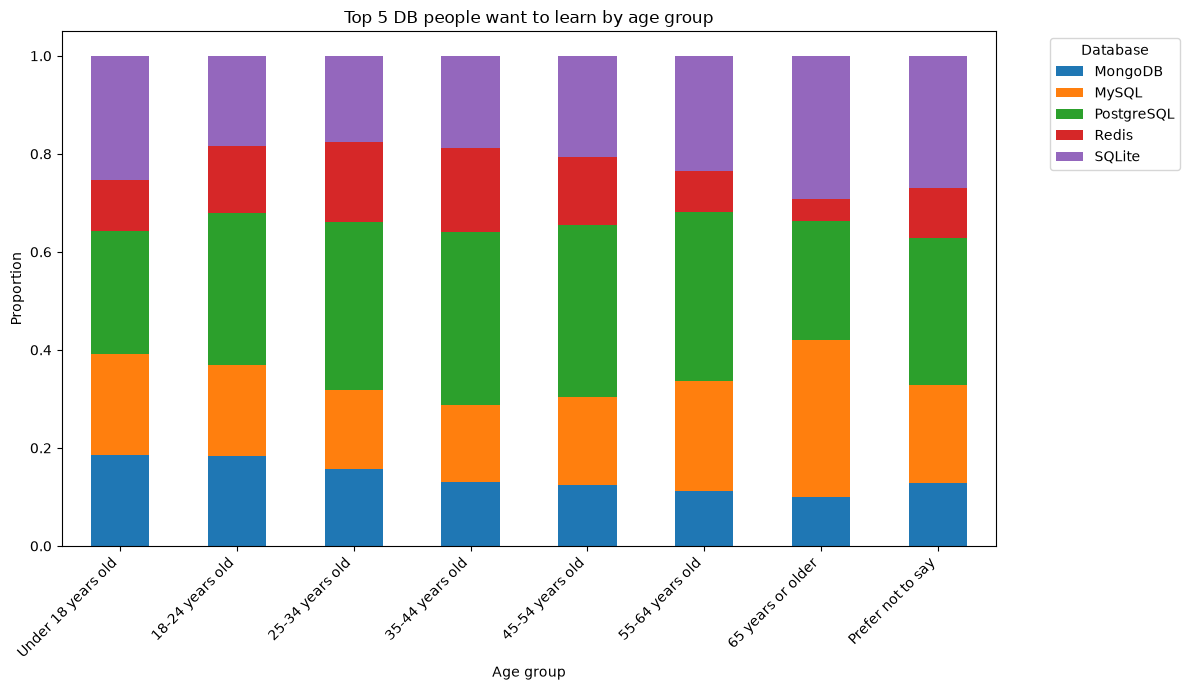

In [45]:
##Write your code here
db=df[['DatabaseWantToWorkWith','Age']].dropna()
db['DatabaseWantToWorkWith']= db['DatabaseWantToWorkWith'].str.split(';')
db=db.explode('DatabaseWantToWorkWith')
top_db= db['DatabaseWantToWorkWith'].value_counts().head(5).index
mask=db['DatabaseWantToWorkWith'].isin(top_db)
db=db[mask]
db_counts=db.groupby(['Age', 'DatabaseWantToWorkWith']).size().unstack().fillna(0)
db_prop=db_counts.div(db_counts.sum(axis=1), axis= 0)

db_prop = db_prop.reindex([a for a in age_order if a in db_prop.index])
db_prop.plot(kind='bar', stacked=True, figsize=(12, 7)) 
plt.title('Top 5 DB people want to learn by age group') 
plt.xlabel('Age group') 
plt.ylabel('Proportion') 
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Database', bbox_to_anchor=(1.05, 1)) 
plt.tight_layout() 
plt.show() 

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


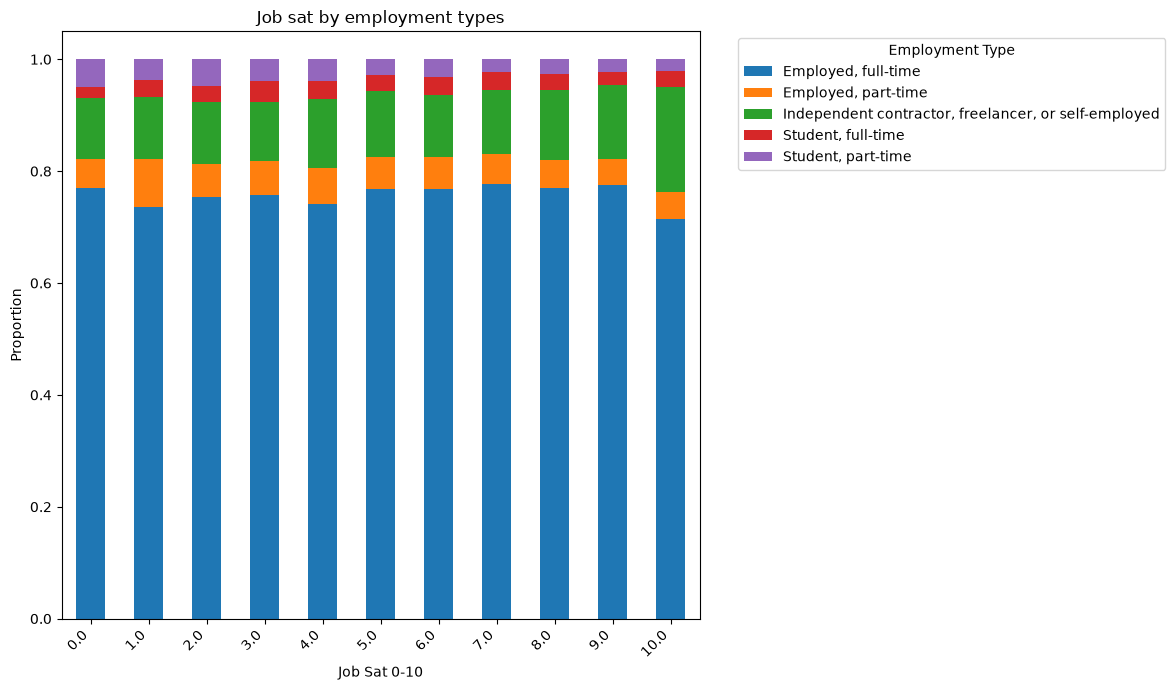

In [58]:
##Write your code here
emp=df[['JobSat', 'Employment']].dropna()
emp['Employment']=emp['Employment'].str.split(';')
emp=emp.explode('Employment')
top_sat= emp['Employment'].value_counts().head(5).index
mask=emp['Employment'].isin(top_sat)
emp=emp[mask]
sat_count= emp.groupby(['JobSat', 'Employment']).size().unstack().fillna(0)
sat_prop=sat_count.div(sat_count.sum(axis=1), axis=0)

sat_prop.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Job sat by employment types') 
plt.xlabel('Job Sat 0-10') 
plt.ylabel('Proportion') 
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1)) 
plt.tight_layout() 
plt.show() 

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


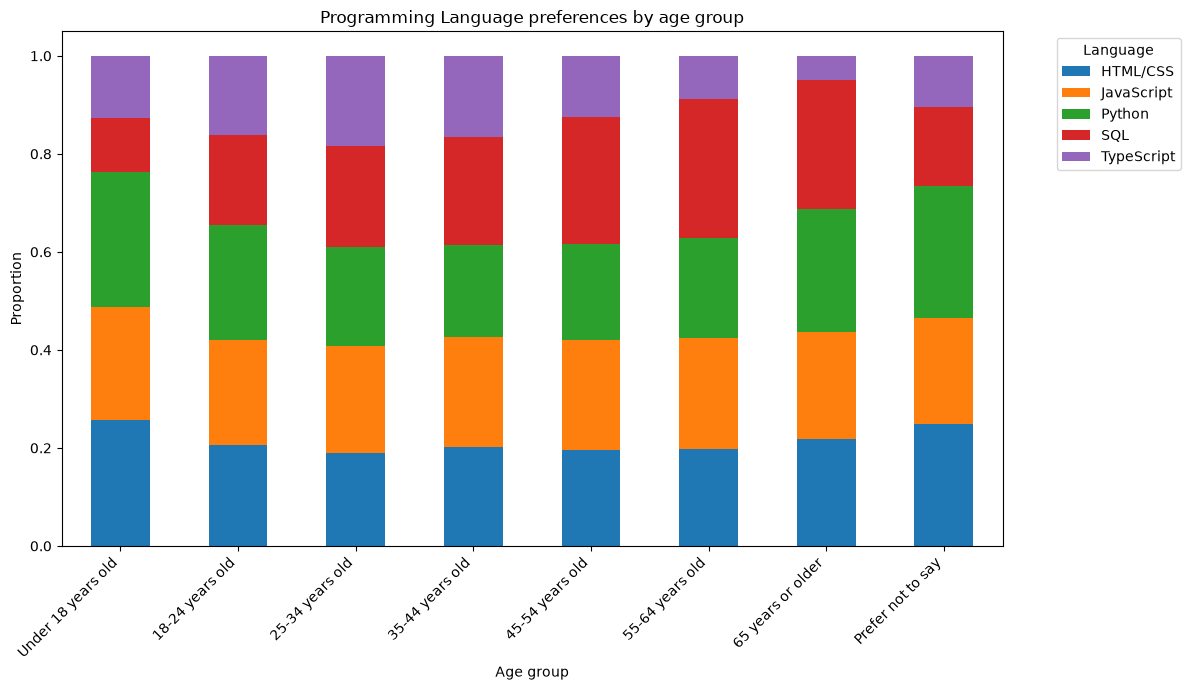

In [71]:
##Write your code here
lang=df[['Age', 'LanguageAdmired']].dropna()
lang['LanguageAdmired']= lang['LanguageAdmired'].str.split(';')
lang=lang.explode('LanguageAdmired') 
top_lang= lang['LanguageAdmired'].value_counts().head(5).index
mask=lang['LanguageAdmired'].isin(top_lang)
lang=lang[mask]
lang_counts=lang.groupby(['Age', 'LanguageAdmired']).size().unstack().fillna(0)
lang_prop=lang_counts.div(lang_counts.sum(axis=1), axis= 0)

lang_prop= lang_prop.reindex([a for a in age_order if a in lang_prop.index])

lang_prop.plot(kind= 'bar', stacked=True, figsize=(12, 7))
plt.title('Programming Language preferences by age group')
plt.xlabel('Age group') 
plt.ylabel('Proportion') 
plt.legend(title='Language', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right') 
plt.tight_layout() 
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


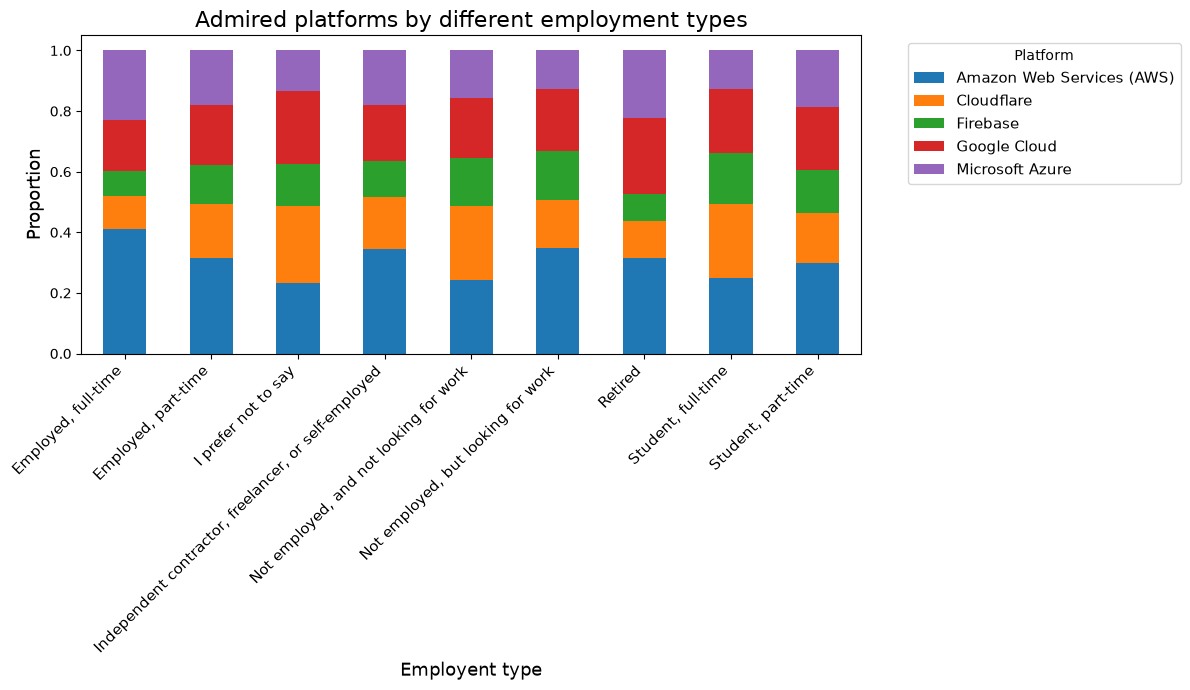

In [91]:
##Write your code here
tech= df[['Employment', 'PlatformAdmired']].dropna()
tech['Employment']=tech['Employment'].str.split(';') 
tech['PlatformAdmired']=tech['PlatformAdmired'].str.split(';')
tech=tech.explode('Employment') 
tech=tech.explode('PlatformAdmired') 
top_plat= tech['PlatformAdmired'].value_counts().head(5).index

mask=tech['PlatformAdmired'].isin(top_plat) 
tech=tech[mask]
plat_counts=tech.groupby(['Employment', 'PlatformAdmired']).size().unstack().fillna(0)

plat_prop=plat_counts.div(plat_counts.sum(axis=1), axis=0) 

plat_prop.plot(kind='bar', stacked=True, figsize=(12, 7)) 
plt.title('Admired platforms by different employment types', fontsize =16)
plt.xlabel('Employent type', fontsize= 13) 
plt.ylabel('Proportion', fontsize=13) 
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), fontsize=11) 
plt.xticks(rotation=45, ha='right', fontsize=11) 
plt.tight_layout() 
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
